<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module3_Lab2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 — Exploratory Data Analysis (Lab)
**Computer Vision · Machine Learning for Vision**

Uses scikit-learn's built-in **wine** dataset. Swap in your own CSV with `pd.read_csv` if you prefer.

## 1. Load the data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_wine

df = load_wine(as_frame=True).frame     # 13 features + 'target' (classes 0,1,2)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2. Analyzing the data
Each summary is `print`ed so it actually shows (a notebook auto-displays only the *last* expression in a cell).

In [2]:
print("shape:", df.shape)
df.info()
print("\nSummary statistics:\n", df.describe().T[["mean","std","min","max"]])
print("\ncolumns:", df.columns.tolist())

shape: (178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    f

## 3. Missing values, duplicates & uniqueness

In [3]:
print("Missing per column:\n", df.isnull().sum().to_string())
print("\nDuplicate rows:", df.duplicated().sum())     # duplicated(), not nunique()
print("\nUnique values per column:\n", df.nunique().to_string())

Missing per column:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0

Duplicate rows: 0

Unique values per column:
 alcohol                         126
malic_acid                      133
ash                              79
alcalinity_of_ash                63
magnesium                        53
total_phenols                    97
flavanoids                      132
nonflavanoid_phenols             39
proanthocyanins                 101
color_intensity                 132
hue                              78
od280/od315_of_diluted_wines    122
proline                 

## 4. Univariate analysis — class counts

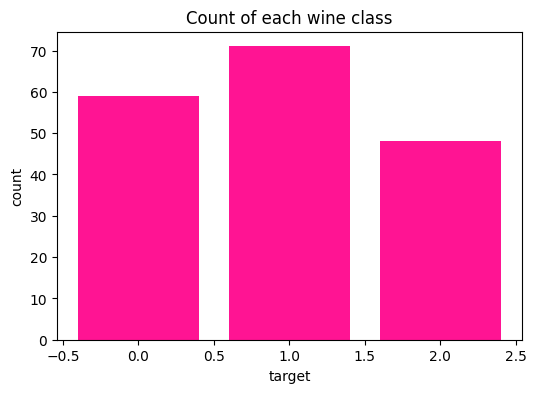

In [4]:
counts = df["target"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts, color="deeppink")
plt.title("Count of each wine class")
plt.xlabel("target")
plt.ylabel("count")
plt.show()

## 5. Distributions with skewness (KDE)

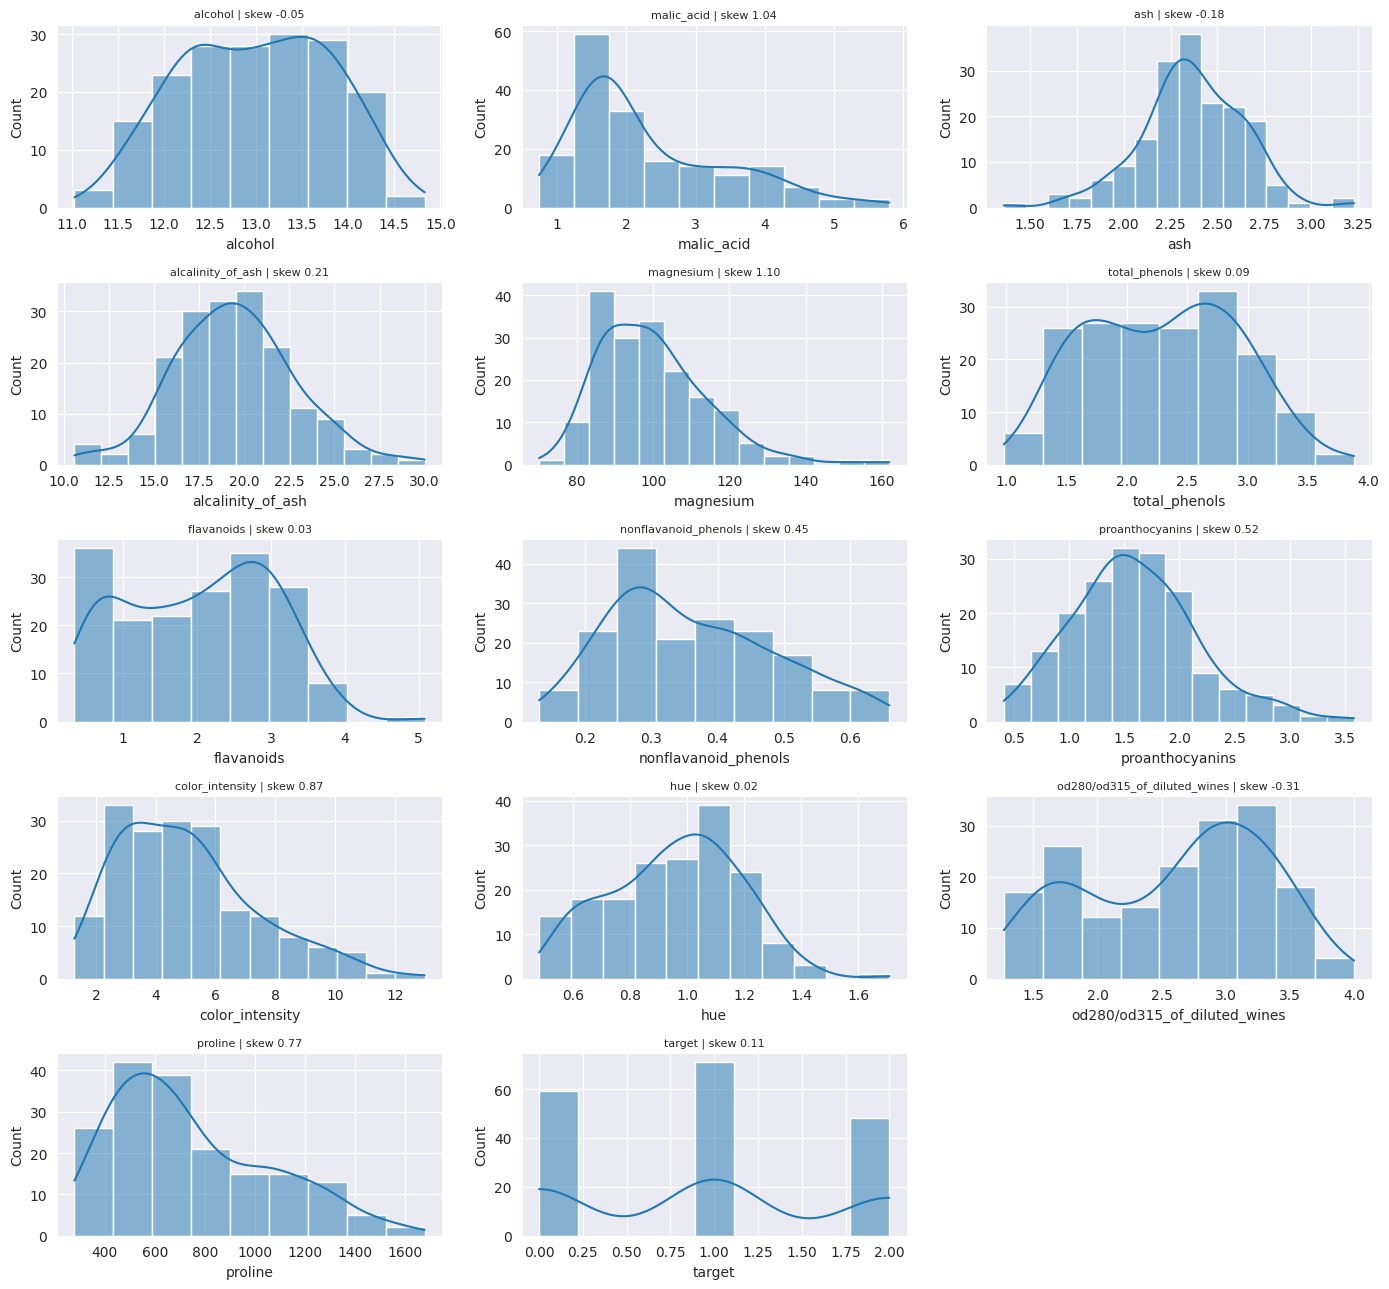

In [5]:
sns.set_style("darkgrid")
num_cols = df.select_dtypes(include=["int64","float64"]).columns
rows = (len(num_cols) + 2) // 3
plt.figure(figsize=(14, rows*2.6))
for i, feat in enumerate(num_cols, 1):
    plt.subplot(rows, 3, i)
    sns.histplot(df[feat], kde=True)
    plt.title(f"{feat} | skew {df[feat].skew():.2f}", fontsize=8)
plt.tight_layout(); plt.show()

## 6. Bivariate analysis — correlation & pair plot

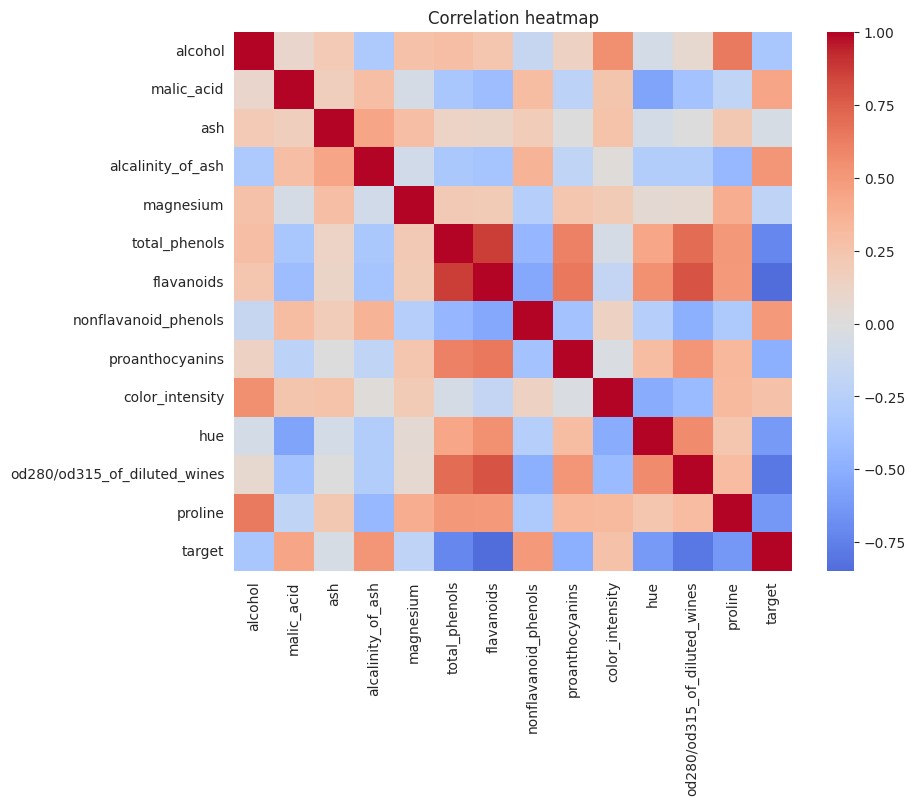

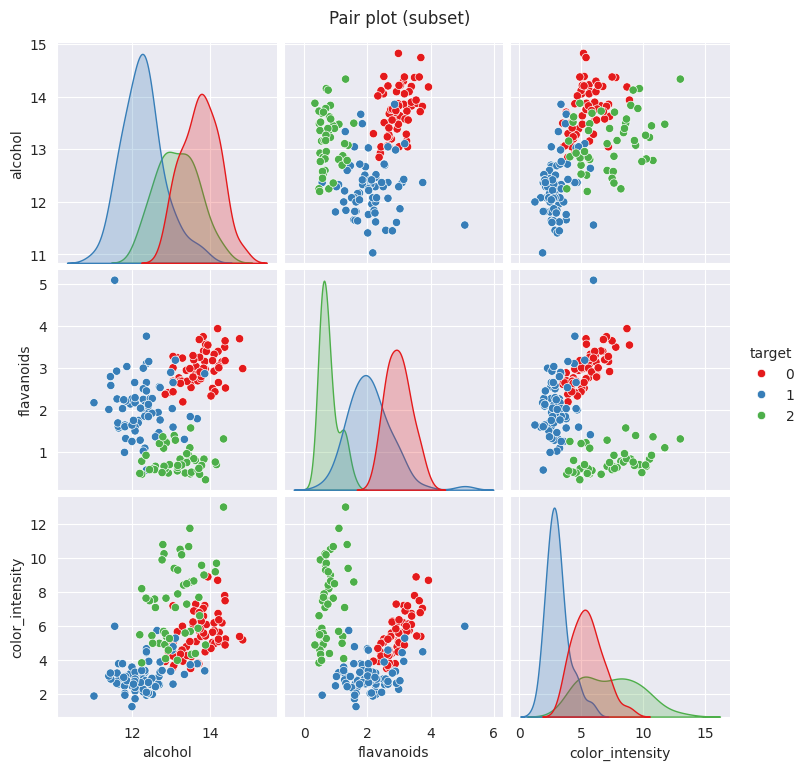

In [6]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap"); plt.show()

subset = ["alcohol", "flavanoids", "color_intensity", "target"]
sns.pairplot(df[subset], hue="target", palette="Set1")   # pairplot builds its own figure
plt.suptitle("Pair plot (subset)", y=1.02); plt.show()